# Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

## Continuar desde la Parte III
* EN LA SECCION SIGUIENTE SE DEJA EL DATAFRAME COMO QUEDO EN LA PARTE 3


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/retail_sales_dataset.csv")

#cambiar columna date a datetime
df['Date'] = pd.to_datetime(df['Date'])
# Extraer el mes de la columna Date y crear una nueva columna
df['Mes'] = df['Date'].dt.month
# Crear una nueva columna con el nombre completo del mes
df['nombreMes'] = df['Date'].dt.month_name()

#Normalizacion de Datos
def NormalizCol(columna):
    valores_min = columna.min()
    valores_max = columna.max()
    return (columna - valores_min) / (valores_max - valores_min)

# Aplicarlo la normalizacion a la columna 'total'
df['NormTotalAmount'] = NormalizCol(df['Total Amount'])

#creando variable categorica como Tipo de Venta, si la venta fue Baja, Media o Alta
df['TipoVenta'] = pd.qcut(df['Total Amount'], q=3, labels=['Baja', 'Media', 'Alta'])

#Calcula la desviación de cada venta respecto a la media de su grupo.
#se calcula el promedio por categoria alta, media, baja
promedios = df.groupby('TipoVenta')['Total Amount'].mean()

#creamos funcion para calcular desviacion
#idea salio desde: https://blog.finxter.com/calculating-mean-absolute-deviation-in-dataframe-rows-and-columns-using-python/
#manteniendo la solicitud que fuese usando apply
def desviacion(fila):
    return fila['Total Amount'] - promedios[fila['TipoVenta']]

#Se crea nueva columna aplicando la funcion anterior
df['Desviacion'] = df.apply(desviacion, axis=1)

C:\Users\jr_ca\AppData\Local\Temp\ipykernel_32520\2059028715.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promedios = df.groupby('TipoVenta')['Total Amount'].mean()


## Análisis Descriptivo y Visualización
* Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
* Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
* Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
* Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
* Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

## Generar un Pull Request en GitHub
* Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.

In [2]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,Mes,NormTotalAmount,Desviacion
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,6.549000,0.218228,-1.000444e-14
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,1.000000,0.000000,-6.160535e+02
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,4.000000,0.017722,-1.101136e+02
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,6.000000,0.055696,-1.011364e+01
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,10.000000,0.443038,2.216332e+01
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,12.000000,1.000000,7.839465e+02
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,3.452755,0.283543,2.502219e+02


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Mes               1000 non-null   int32         
 10  nombreMes         1000 non-null   object        
 11  NormTotalAmount   1000 non-null   float64       
 12  TipoVenta         1000 non-null   category      
 13  Desviacion        1000 non-null   float64       
dtypes: category(1), datetime6

---
* Graficamos las vental totales en el tiempo del dataset
* tambien graficamos con lineas, la descomposicion del grafico en el tipo de venta (alta, media, baja)
---

C:\Users\jr_ca\AppData\Local\Temp\ipykernel_32520\1909604346.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mensual_tipo = df.groupby(['Mes', 'TipoVenta'])['Total Amount'].sum().reset_index()


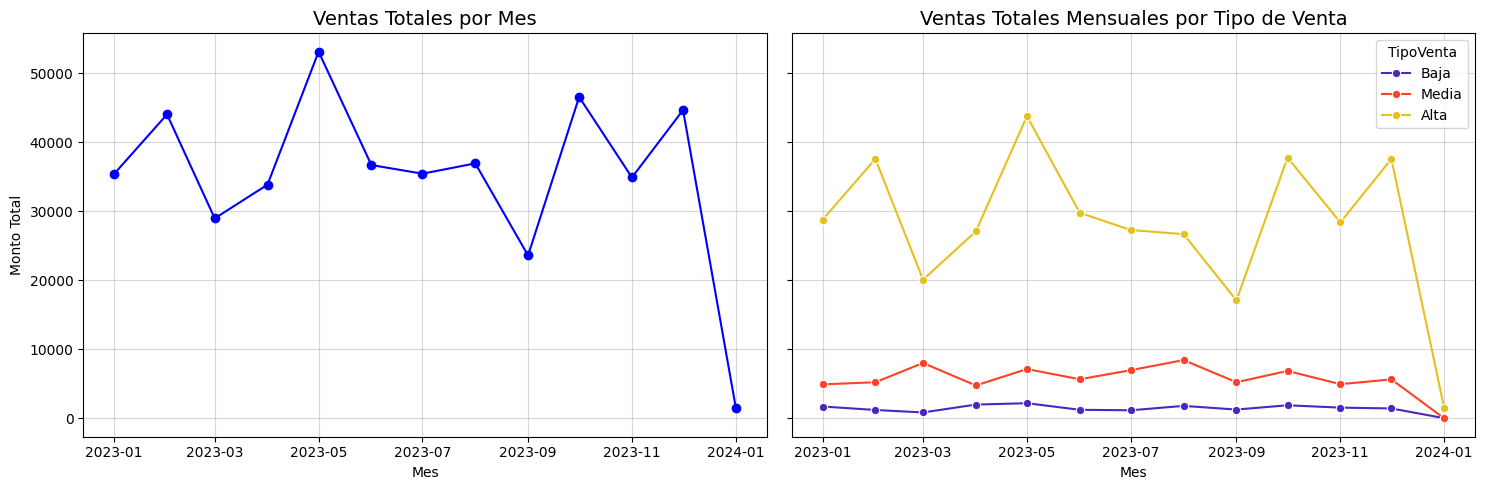

In [ ]:
# Se crean los grupos de datos para graficar
# https://www.askpython.com/python-modules/pandas/groupby-to-group-dataframe-by-month
df_mensual_total = df.groupby(df['Date'].dt.to_period('M')).sum(numeric_only=True).reset_index()
df_mensual_total['Date'] = df_mensual_total['Date'].dt.to_timestamp()
df['Mes'] = df['Date'].dt.to_period('M').dt.to_timestamp()

#se crea un grupo por mes y tipo de venta, para las vental totales
df_mensual_tipo = df.groupby(['Mes', 'TipoVenta'])['Total Amount'].sum().reset_index()


fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

axes[0].plot(df_mensual_total['Date'], df_mensual_total['Total Amount'], marker='o', linestyle='-', color='b')
axes[0].set_title('Ventas Totales por Mes', fontsize=14)
axes[0].set_ylabel('Monto Total')
axes[0].set_xlabel('Mes')
axes[0].grid(True, alpha=0.5)

sns.lineplot(data=df_mensual_tipo, x='Mes', y='Total Amount', hue='TipoVenta', palette='CMRmap', marker='o', ax=axes[1]) # 'ax=axes[1]' indica que va en el segundo espacio
axes[1].set_title('Ventas Totales Mensuales por Tipo de Venta', fontsize=14)
axes[1].set_xlabel('Mes')
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

---
* La forma del grafico de ventas la entrega las ventas altas.
* Las ventas bajan suben la ganancia total, pero no son competencia al ingreso mayor.
---

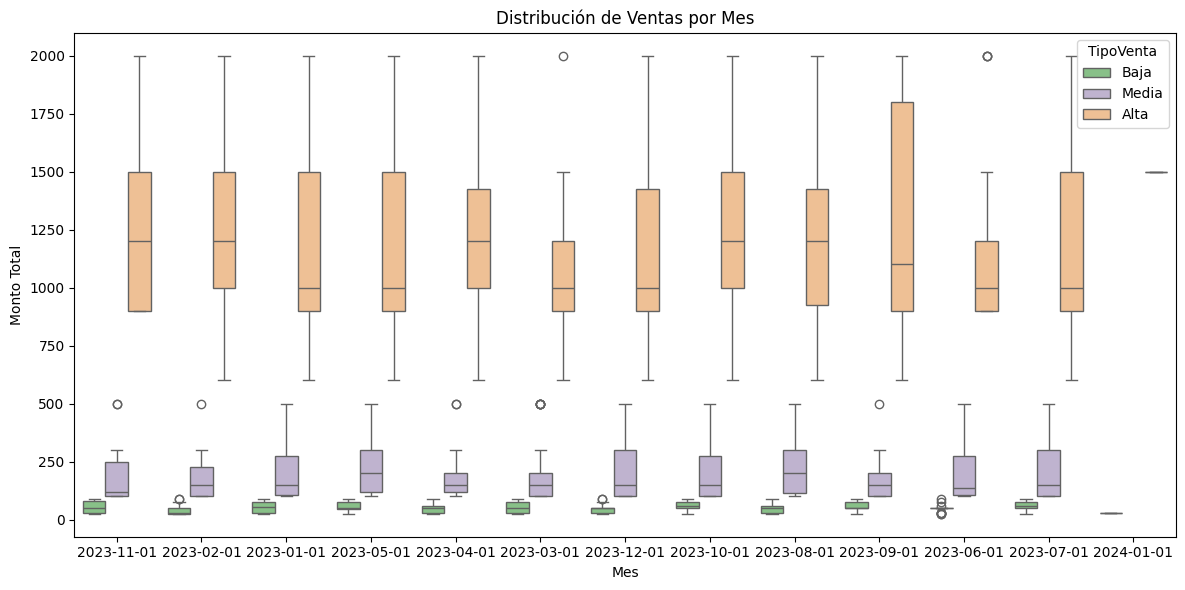

In [72]:
#crear boxplot para visualizar la distribucion del tipo de venta mensual
plt.figure(figsize=(12, 6))
sns.boxplot(x='Mes', y='Total Amount', data=df, hue='TipoVenta', palette='Accent')
plt.title('Distribución de Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Monto Total')
plt.tight_layout()
plt.show()

---
* Nuevamente se observa el gran efecto del tipo de venta "Alta"
* Al parecer existiria una compra por monto maximo por cada mes. Eso se observa con los outliers en Marzo y Junio.
* Situacion similar ocurre en las compras de tipo "Media". Si bien se observa mayor diversidad en distribucion y rango de ese tipo de compras, siempre se ve que a un "Monto Total" de 500, o llega los bigotes del boxplot o aparece un outlier en él.
---

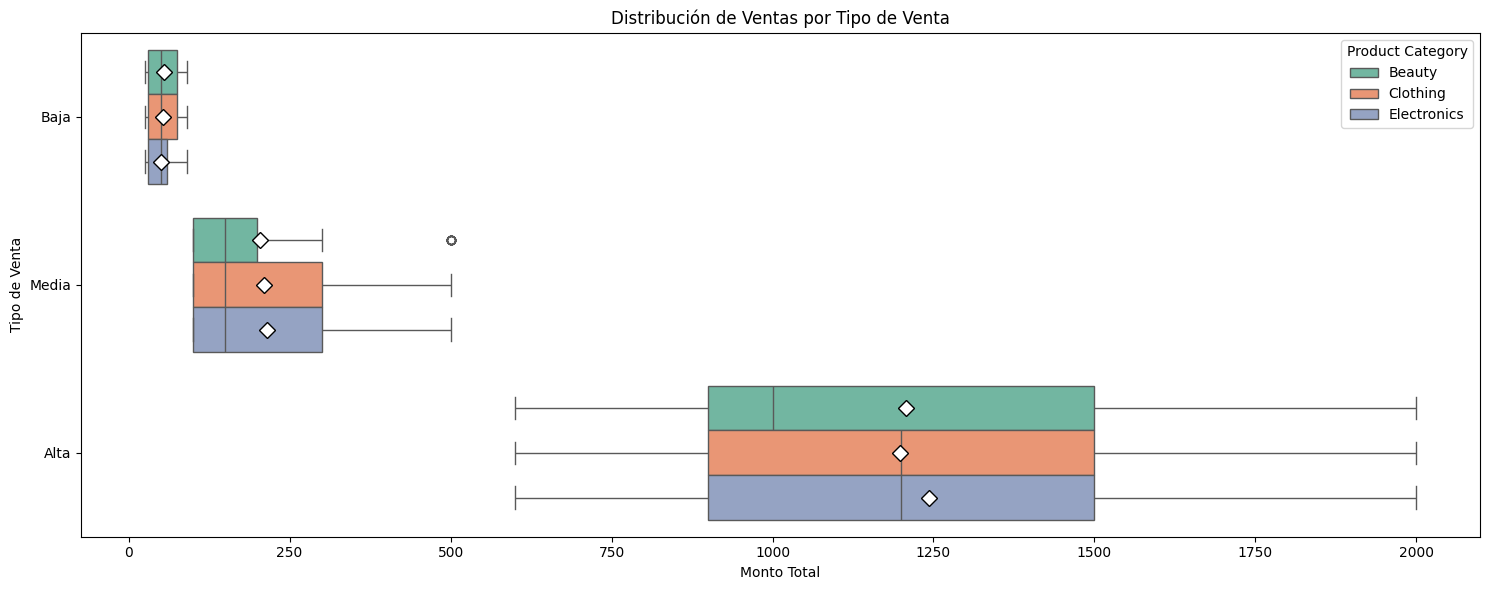

In [75]:
#crear boxplot horizontales para visualizar la distribucion de las ventas por tipo de venta
plt.figure(figsize=(15, 6))
sns.boxplot(x='Total Amount', y='TipoVenta', data=df, hue='Product Category', palette='Set2', showmeans=True, meanprops={"marker":"D", "markersize":"8", "markerfacecolor":"white", "markeredgecolor":"black"})

plt.title('Distribución de Ventas por Tipo de Venta')
plt.xlabel('Monto Total')
plt.ylabel('Tipo de Venta')
plt.tight_layout()
plt.show()

---
* En compras altas, vemos un promedio y mediana relativamente similar (el promedio de electronica es algo mas alto), excepto en productos de belleza donde se observa una mediana mucho mas baja. Es posible que en distribucion de precios, Beauty tenga mas productos a precios menores que Ropa o Electronica.
* En compras medias, los promedios se mantienen relativamente similares, aunque la distribucion es menor en productos de belleza. Y su promedio se ve influenciado por el outlier de Monto Total = 500.
* En compras bajas, se observa una menos distribucion en el precios de electronicos, posiblemente porque la cantidad de productos de esa categoria es menor a menores precios
---

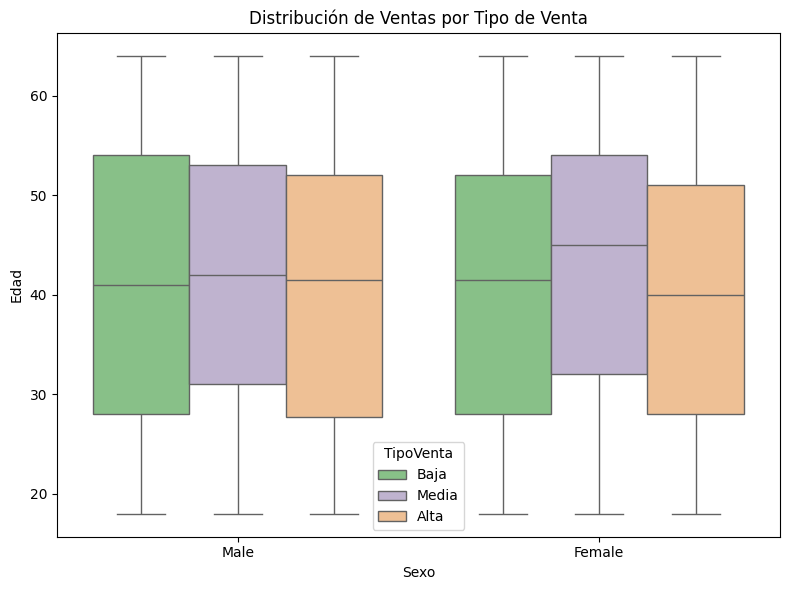

In [33]:
#crear boxplot para visualizar la distribucion de las ventas por tipo de venta
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Age', data=df, hue='TipoVenta', palette='Accent')
plt.title('Distribución de Ventas por Tipo de Venta')
plt.xlabel('Sexo')
plt.ylabel('Edad')
plt.tight_layout()
plt.show()

---
* No se observa una mayor influencia en la edad y el sexo de quien realiza las compras
* El grafico solo mostraría que la distribucion de edad en mujeres que realizan compras Medias es mayor, y que la edad de mujeres que realizan compras Altas es menor
---

Text(0.5, 1.0, 'Matriz de Correlación')

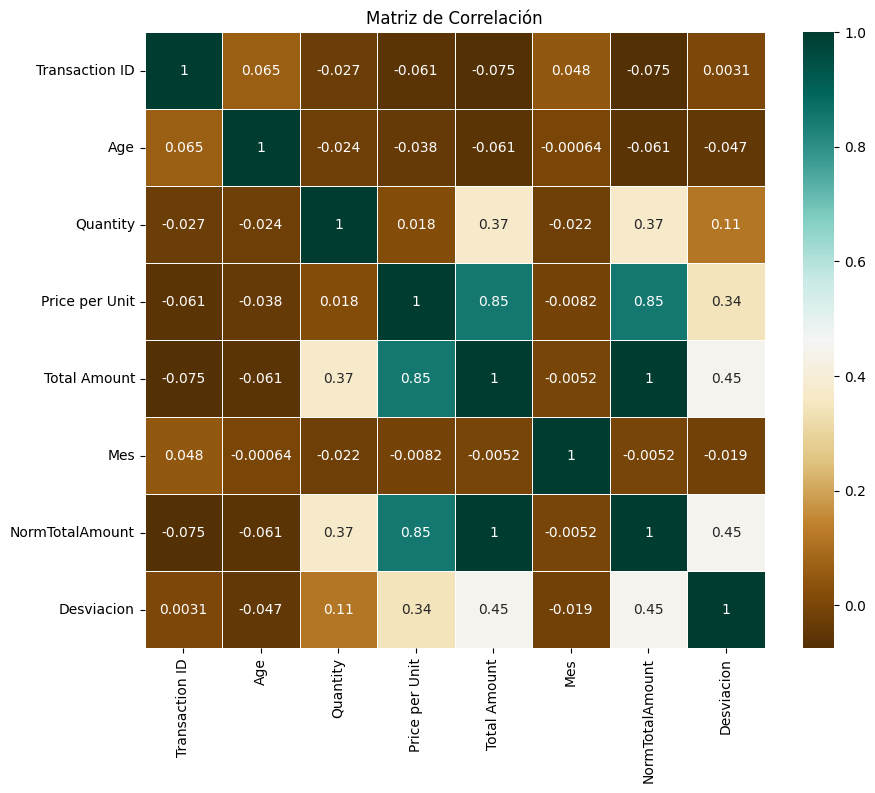

In [ ]:
#crear matriz de correlacion de df para pensar en crear graficos de dispersion
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='BrBG', linewidths=0.5)
plt.title('Matriz de Correlación')

---
* No se observan correlaciones inversas entre las variables. Su valor mas negativo es -0.075
* Pero tampooco se observan fuertes correlaciones entre variables. La mayoria de correlaciones de columnas numericas estan cercanas al cero
* se decide graficar la relacion entre Precio por Unidad y Total
---

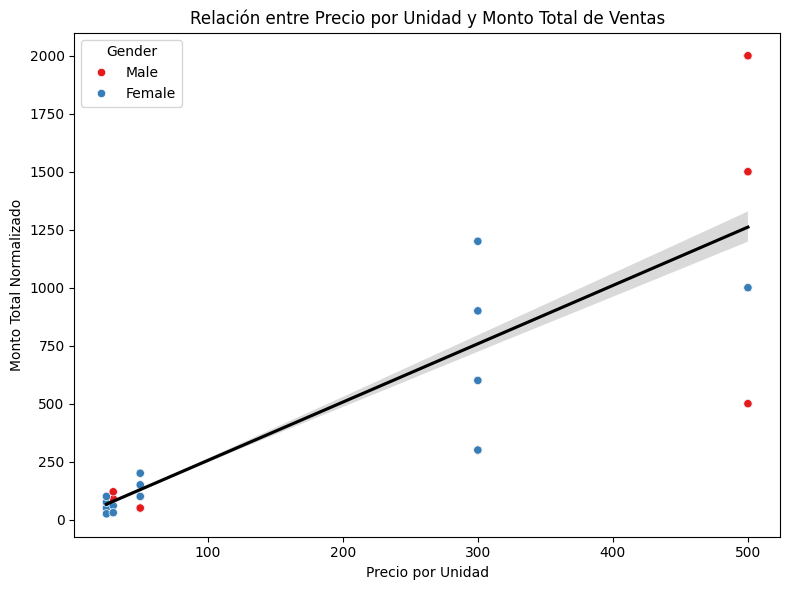

In [78]:
#crear scatter plot para visualizar la relacion entre precio por unidad y monto total normalizado, diferenciando por sexo
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Price per Unit', y='Total Amount', data=df, hue='Gender', palette='Set1')
sns.regplot(x='Price per Unit', y='Total Amount', data=df, scatter=False, color='black')
plt.title('Relación entre Precio por Unidad y Monto Total de Ventas')
plt.xlabel('Precio por Unidad')
plt.ylabel('Monto Total Normalizado')
plt.tight_layout()
plt.show()

---
* Se intento inicialmente colorear por tipo de venta, pero solo se mostraba el grupo cercano al origen como baja, los puntos entre 300 a 500 como Alta y el resto como media
* Este grafico nos mostraria que los hombres serian responsables de las compras mas "Altas", mientras que las mujeres dominan las compras "Medias"
---